# 9.1 ***门控循环单元GRU***

### 9.1.1 *从零实现门控循环单元*

d2l的torch的3638行结尾注释

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
batch_size, num_steps = 32, 35

d2l.DATA_HUB['time_machine'] = (d2l.DATA_URL + 'timemachine.txt'
                                ,'090b5e7e70c295757f55df93cb0a180b9691891a')
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### 9.1.2 *初始化参数*

In [3]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size = shape, device=device) * 0.01
    
    def three():
        return (normal((num_inputs, num_hiddens)),
                 normal((num_hiddens, num_hiddens)),
                   torch.zeros(num_hiddens, device=device))
    
    W_xz, W_hz, b_z = three()
    W_xr, W_hr, b_r = three()
    W_xh, W_hh, b_h = three()

    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)

    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

### 9.1.3 *定义模型*

In [4]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),)

In [5]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    (H,) = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.tanh((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

### 9.1.4 *训练与预测*

困惑度 1.1, 88316.7 词元/秒 cpu
time traveller with a slight accession ofcheerfulness really thi
travelleryou can show black is white by argument said filby


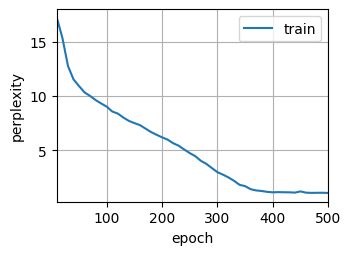

In [6]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params,
                            init_gru_state, gru)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

### 9.1.5 *简洁实现*

3638行不需要注释

In [ ]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1

In [ ]:
num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs, num_hiddens)
model = d2l.RNNModel(gru_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

# 9.2 ***长短期记忆网络***

### 9.2.1 *从零实现LSTM*

3638行需要注释

可以把C_t-1理解成长记忆，H_t-1理解成短记忆；  
H可以理解成辅助判断当前输入是否有用，但决定X和H生成三个门还是各自参数；  
1:输入X先和H生成遗忘门判断这个输入中哪些不要保留到长记忆C中，再和长记忆做点积生成遗忘了这个输入的长记忆；  
2:但是还没有判断输入X中哪些要留到长记忆中，所以生成一个输入门，但长记忆没法把旧的记忆中的被遗忘的相同信息找回来，那只能先搞一个候选记忆，再让输入门与候选记忆点积生成要保存到长记忆中的信息，再与已经遗忘了信息的长记忆单元相加生成新的长记忆C；  
3:最后，再更新新的短记忆辅助判断H，用输出门与长记忆中提取的信息点积生成新的H。 

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
batch_size, num_steps = 32, 35

d2l.DATA_HUB['time_machine'] = (d2l.DATA_URL + 'timemachine.txt'
                                ,'090b5e7e70c295757f55df93cb0a180b9691891a')
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### 9.2.2 *初始化参数*

In [3]:
def get_lstm_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size = shape, device=device) * 0.01
    
    def three():
        return (normal((num_inputs, num_hiddens)),
                 normal((num_hiddens, num_hiddens)),
                   torch.zeros(num_hiddens, device=device))
    
    W_xi, W_hi, b_i = three()
    W_xf, W_hf, b_f = three()
    W_xo, W_ho, b_o = three()
    W_xc, W_hc, b_c = three()

    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)

    params = [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o,
              W_xc, W_hc, b_c, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

### 9.2.3 *定义模型*

In [4]:
def init_lstm_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),
            torch.zeros((batch_size, num_hiddens), device=device))

In [5]:
def lstm(inputs, state, params):
    [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc, b_c, W_hq, b_q] = params
    (H, C) = state
    outputs = []
    for X in inputs:
        I = torch.sigmoid((X @ W_xi) + (H @ W_hi) + b_i)
        F = torch.sigmoid((X @ W_xf) + (H @ W_hf) + b_f)
        O = torch.sigmoid((X @ W_xo) + (H @ W_ho) + b_o)
        C_tilda = torch.tanh((X @ W_xc) + (H @ W_hc) + b_c)
        C = F * C + I * C_tilda
        H = O * torch.tanh(C)
        Y = (H @ W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H, C)

### 9.2.4 *训练和预测*

困惑度 1.1, 52908.1 词元/秒 cpu


ValueError: not enough values to unpack (expected 2, got 1)

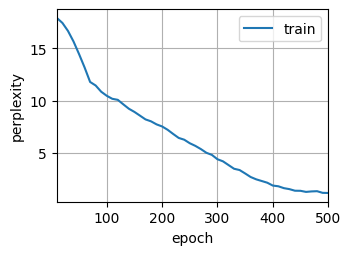

In [6]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_lstm_params,
                            init_lstm_state, lstm)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

### 9.2.5 *简洁实现LSTM*

3638行不需要注释

困惑度 1.1, 64413.5 词元/秒 cpu


IndexError: index 1 is out of bounds for dimension 0 with size 1

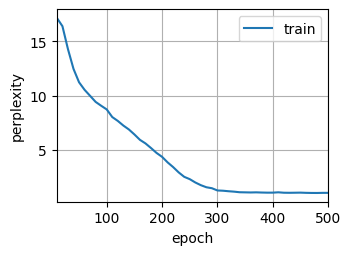

In [8]:
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

# 9.3 ***深度循环神经网络***

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
batch_size, num_steps = 32, 35

d2l.DATA_HUB['time_machine'] = (d2l.DATA_URL + 'timemachine.txt'
                                ,'090b5e7e70c295757f55df93cb0a180b9691891a')
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### 9.3.1 *简洁实现*

In [3]:
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
device = d2l.try_gpu()
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)

### 9.3.2 *训练与预测*

困惑度 1.0, 33347.6 词元/秒 cpu
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


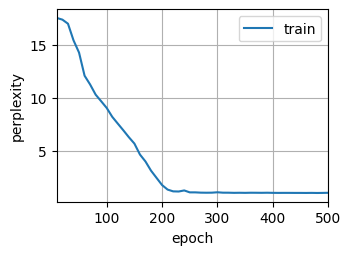

In [5]:
num_epochs, lr= 500, 2
d2l.train_ch8(model, train_iter, vocab, lr*1.0, num_epochs, device)

# 9.4 ***机器翻译与数据集***